## <h3 align="center"> __Johns Hopkins University__</h3>
## <h3 align="center">__Whiting School of Engineering__</h3>
## <h3 align="center">__Engineering for Professionals__</h3>
## <h3 align="center">__685.801 Data Science: Independent Study__</h3>
## <h3 align="center">__Serialized Submodel Comparison__</h3>

---

- **Purpose:** Compare routers and experts using serialized JSON runs rather than retraining.
- **Primary metric:** `AvgAcc Micro F1`.
- **Statistical testing:** paired Wilcoxon signed-rank with Benjamini-Hochberg correction.
- **How to use:**
  1. Update the results path cell if needed.
  2. Run the notebook top to bottom.
  3. Review the summary tables, paired deltas, significance tables, and separate figures.

---

In [21]:
! pip install -q numpy pandas matplotlib seaborn scipy statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Dom\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [22]:
# Environment Check
import sys, platform
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
try:
    import numpy as np, pandas as pd, matplotlib, seaborn, scipy, statsmodels
    print(f"numpy:      {np.__version__}")
    print(f"pandas:     {pd.__version__}")
    print(f"matplotlib: {matplotlib.__version__}")
    print(f"seaborn:    {getattr(seaborn, '__version__', 'unknown')}")
    print(f"scipy:      {scipy.__version__}")
    print(f"statsmodels:{statsmodels.__version__}")
except Exception as e:
    print("Optional packages missing or version check failed:", e)
    print("Use the command in the cell above to install necessary packages.")

Python: 3.12.10
Platform: Windows-11-10.0.26200-SP0
numpy:      1.26.4
pandas:     2.2.2
matplotlib: 3.9.2
seaborn:    0.13.2
scipy:      1.14.1
statsmodels:0.14.4


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

from plots import load_serialized_training_runs, build_serialized_results_table

In [ ]:
RESULTS_DIR = Path('./')
RESULT_GLOB = '**/*.json'

all_paths = sorted(RESULTS_DIR.glob(RESULT_GLOB))
result_paths = [path for path in all_paths if " + " in str(path)]
if not result_paths:
    raise FileNotFoundError('No JSON files were found. Update RESULTS_DIR or RESULT_GLOB before continuing.')

pd.DataFrame({'Result File': [str(path) for path in result_paths]})

,Result File
0,results\ConvNeXt + Layered Router + MLP Expert...
1,results\ConvNeXt + Layered Router + ResMLP Exp...
2,results\ConvNeXt + Layered Router + Transforme...
3,results\ConvNeXt + MLP Router + MLP Experts_20...
4,results\ConvNeXt + MLP Router + ResMLP Experts...
5,results\ConvNeXt + MLP Router + Transformer Ex...
6,results\MobileNet + Layered Router + MLP Exper...
7,results\MobileNet + Layered Router + ResMLP Ex...
8,results\MobileNet + Layered Router + Transform...
9,results\MobileNet + MLP Router + MLP Experts_2...


In [25]:
runs = load_serialized_training_runs(result_paths)
comparison_df = build_serialized_results_table(runs)
primary_metric = 'AvgAcc Micro F1'
primary_bwt_metric = 'Backward Transfer Micro F1'
primary_fwt_metric = 'Forward Transfer Micro F1'
primary_forgetting_metric = 'Average Forgetting Micro F1'
primary_validation_metric = 'Full Validation Micro F1'

summary_columns = [
    column for column in [
        'Model',
        primary_metric,
        primary_bwt_metric,
        primary_fwt_metric,
        primary_forgetting_metric,
        primary_validation_metric,
        'Post Training ECE',
        'Post Training Router Entropy',
        'Post Training Expected Expert Calls',
        'Total Compute Time (s)',
        'Num Parameters',
    ] if column in comparison_df.columns
]
summary_df = comparison_df.loc[:, summary_columns].copy()
summary_df = summary_df.sort_values(by=[primary_metric, primary_validation_metric], ascending=False).reset_index(drop=True)
display(summary_df.style.format({
    primary_metric: '{:.4f}',
    primary_bwt_metric: '{:.4f}',
    primary_fwt_metric: '{:.4f}',
    primary_forgetting_metric: '{:.4f}',
    primary_validation_metric: '{:.4f}',
    'Post Training ECE': '{:.4f}',
    'Post Training Router Entropy': '{:.4f}',
    'Post Training Expected Expert Calls': '{:.4f}',
    'Total Compute Time (s)': '{:.1f}',
    'Num Parameters': '{:,.0f}',
}))

,Model,AvgAcc Micro F1,Backward Transfer Micro F1,Forward Transfer Micro F1,Average Forgetting Micro F1,Full Validation Micro F1,Post Training ECE,Post Training Router Entropy,Post Training Expected Expert Calls,Total Compute Time (s),Num Parameters
0,ConvNeXt + Layered Router + MLP Experts_2026-06-28,0.9486,-0.0632,-0.1280,0.0632,0.9470,0.0084,0.1365,2.0000,1411.3,"29,615,008"
1,ConvNeXt + MLP Router + MLP Experts_2026-06-28,0.9407,-0.0812,-0.1208,0.0812,0.9380,0.0176,1.5120,2.0000,1363.4,"28,429,216"
2,MobileNet + Layered Router + Transformer Experts_2026-06-28,0.9390,-0.0874,-0.0555,0.0874,0.9355,0.0489,0.6749,2.0000,332.1,"2,434,866"
3,ConvNeXt + MLP Router + Transformer Experts_2026-06-28,0.9318,-0.0876,-0.0812,0.0876,0.9290,0.0163,0.9320,2.0000,1370.3,"28,663,840"
4,MobileNet + MLP Router + MLP Experts_2026-06-28,0.9254,-0.1041,-0.1502,0.1041,0.9215,0.0344,1.5797,2.0000,364.8,"1,385,778"
5,MobileNet + MLP Router + Transformer Experts_2026-06-28,0.9230,-0.1111,-0.0260,0.1111,0.9187,0.0504,1.3501,2.0000,341.0,"1,766,706"
6,ConvNeXt + Layered Router + Transformer Experts_2026-06-28,0.9171,-0.1063,-0.1441,0.1063,0.9140,0.0246,0.7448,2.0000,1365.6,"29,849,632"
7,MobileNet + Layered Router + ResMLP Experts_2026-06-28,0.9156,-0.1204,-0.1201,0.1204,0.9109,0.0116,1.3338,2.0000,321.8,"2,460,210"
8,MobileNet + Layered Router + MLP Experts_2026-06-28,0.9127,-0.1200,-0.1253,0.1200,0.9084,0.0107,1.3361,2.0000,313.0,"2,053,938"
9,ConvNeXt + Layered Router + ResMLP Experts_2026-06-28,0.9051,-0.1301,-0.1681,0.1301,0.9003,0.0256,0.0433,2.0000,1358.7,"30,023,584"


In [26]:
def add_model_component_columns(df: pd.DataFrame):
    if 'Model' not in df.columns:
        raise KeyError("Expected a 'Model' column in the comparison dataframe.")

    parts = df['Model'].astype(str).str.split(r'\s+\+\s+', expand=True)
    if parts.shape[1] < 3:
        raise ValueError("Expected model names in the form 'Generalist + Router + Expert'.")

    out = df.copy()
    out['Generalist'] = parts[0]
    out['Router'] = parts[1]
    out['Expert'] = parts[2]
    return out


def flatten_multiindex_columns(df: pd.DataFrame):
    flattened = []
    for col in df.columns:
        if isinstance(col, tuple):
            flattened.append(' '.join(str(part) for part in col if part).strip())
        else:
            flattened.append(str(col))
    result = df.copy()
    result.columns = flattened
    return result


def summarize_component_performance(df: pd.DataFrame, component_col: str, metrics: list[str]):
    available_metrics = [metric for metric in metrics if metric in df.columns]
    if not available_metrics:
        return pd.DataFrame()

    summary = (
        df.groupby(component_col)[available_metrics]
        .agg(['mean', 'std', 'min', 'max', 'count'])
        .reset_index()
    )
    summary = flatten_multiindex_columns(summary)
    sort_column = f'{available_metrics[0]} mean'
    if sort_column in summary.columns:
        summary = summary.sort_values(sort_column, ascending=False).reset_index(drop=True)
    return summary


def build_component_delta_table(df: pd.DataFrame, component_col: str, baseline_name: str, compare_names: list[str], fixed_cols: list[str], metrics: list[str]):
    available_metrics = [metric for metric in metrics if metric in df.columns]
    if not available_metrics:
        return pd.DataFrame()

    rows = []
    for compare_name in compare_names:
        subset = df[df[component_col].isin([baseline_name, compare_name])].copy()
        if subset[component_col].nunique() < 2:
            continue

        pivot = subset.pivot_table(index=fixed_cols, columns=component_col, values=available_metrics, aggfunc='first')
        if baseline_name not in pivot.columns.get_level_values(1):
            continue
        if compare_name not in pivot.columns.get_level_values(1):
            continue

        delta_df = pd.DataFrame(index=pivot.index).reset_index()
        delta_df[component_col] = compare_name
        for metric in available_metrics:
            baseline_key = (metric, baseline_name)
            compare_key = (metric, compare_name)
            if baseline_key not in pivot.columns or compare_key not in pivot.columns:
                continue

            baseline_values = pivot[baseline_key].to_numpy()
            compare_values = pivot[compare_key].to_numpy()
            delta_df[f'{metric} [{baseline_name}]'] = baseline_values
            delta_df[f'{metric} [{compare_name}]'] = compare_values
            delta_df[f'{metric} Delta ({compare_name} - {baseline_name})'] = compare_values - baseline_values

        rows.append(delta_df)

    if not rows:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


def run_paired_component_tests(df: pd.DataFrame, component_col: str, baseline_name: str, compare_names: list[str], fixed_cols: list[str], metrics: list[str]):
    available_metrics = [metric for metric in metrics if metric in df.columns]
    if not available_metrics:
        return pd.DataFrame()

    rows = []
    raw_p_values = []
    p_value_row_indices = []

    for compare_name in compare_names:
        subset = df[df[component_col].isin([baseline_name, compare_name])].copy()
        if subset[component_col].nunique() < 2:
            continue

        pivot = subset.pivot_table(index=fixed_cols, columns=component_col, values=available_metrics, aggfunc='first')
        if baseline_name not in pivot.columns.get_level_values(1):
            continue
        if compare_name not in pivot.columns.get_level_values(1):
            continue

        for metric in available_metrics:
            baseline_key = (metric, baseline_name)
            compare_key = (metric, compare_name)
            if baseline_key not in pivot.columns or compare_key not in pivot.columns:
                continue

            paired = pivot[[baseline_key, compare_key]].dropna()
            if paired.empty:
                continue

            baseline_values = paired[baseline_key].to_numpy(dtype=float)
            compare_values = paired[compare_key].to_numpy(dtype=float)
            deltas = compare_values - baseline_values
            nonzero_deltas = deltas[~np.isclose(deltas, 0.0)]

            p_value = np.nan
            test_name = 'Wilcoxon signed-rank'
            if len(nonzero_deltas) == 0:
                p_value = 1.0
                test_name = 'All deltas are zero'
            elif len(nonzero_deltas) >= 2:
                try:
                    _, p_value = wilcoxon(nonzero_deltas, alternative='two-sided', zero_method='wilcox')
                except ValueError:
                    p_value = np.nan
                    test_name = 'Wilcoxon unavailable'
            else:
                test_name = 'Insufficient non-zero pairs'

            row = {
                component_col: compare_name,
                'Metric': metric,
                'Paired Configurations': len(deltas),
                f'Mean {baseline_name}': baseline_values.mean(),
                f'Mean {compare_name}': compare_values.mean(),
                'Mean Delta': deltas.mean(),
                'Median Delta': np.median(deltas),
                'Std Delta': deltas.std(ddof=0),
                'Raw P Value': p_value,
                'Test': test_name,
            }
            rows.append(row)
            if not np.isnan(p_value):
                raw_p_values.append(p_value)
                p_value_row_indices.append(len(rows) - 1)

    if not rows:
        return pd.DataFrame()

    result = pd.DataFrame(rows)
    result['FDR BH P Value'] = np.nan
    result['Significant @ 0.05'] = False
    if raw_p_values:
        _, corrected, _, _ = multipletests(raw_p_values, method='fdr_bh')
        for row_index, corrected_p in zip(p_value_row_indices, corrected):
            result.loc[row_index, 'FDR BH P Value'] = corrected_p
            result.loc[row_index, 'Significant @ 0.05'] = bool(corrected_p < 0.05)

    return result.sort_values([component_col, 'Metric']).reset_index(drop=True)


def style_component_table(df: pd.DataFrame):
    if df.empty:
        return df

    formatters = {}
    for column in df.columns:
        if pd.api.types.is_numeric_dtype(df[column]):
            if 'count' in column.lower() or 'paired configurations' in column.lower():
                formatters[column] = '{:.0f}'
            elif 'Cost Proxy' in column:
                formatters[column] = '{:.0f}'
            else:
                formatters[column] = '{:.4f}'

    return df.style.format(formatters)

In [27]:
submodel_df = add_model_component_columns(comparison_df)

component_metrics = [
    metric
    for metric in [
        'AvgAcc Micro F1',
        'Backward Transfer Micro F1',
        'Forward Transfer Micro F1',
        'Average Forgetting Micro F1',
        'Full Validation Micro F1',
        'Post Training ECE',
        'Post Training Router Entropy',
        'Post Training Expected Expert Calls',
        'Post Training Cost Proxy',
    ]
    if metric in submodel_df.columns
]

print('Model count by router and expert combination')
display(pd.crosstab(submodel_df['Router'], submodel_df['Expert']))

router_summary_df = summarize_component_performance(submodel_df, 'Router', component_metrics)
expert_summary_df = summarize_component_performance(submodel_df, 'Expert', component_metrics)
display(style_component_table(router_summary_df))
display(style_component_table(expert_summary_df))

router_compare_names = [name for name in submodel_df['Router'].dropna().unique() if name != 'MLP Router']
expert_compare_names = [name for name in submodel_df['Expert'].dropna().unique() if name != 'MLP Experts']
router_delta_metrics = [metric for metric in ['AvgAcc Micro F1', 'Average Forgetting Micro F1', 'Backward Transfer Micro F1', 'Forward Transfer Micro F1', 'Post Training ECE', 'Post Training Router Entropy', 'Post Training Expected Expert Calls'] if metric in submodel_df.columns]
expert_delta_metrics = [metric for metric in ['AvgAcc Micro F1', 'Average Forgetting Micro F1', 'Backward Transfer Micro F1', 'Forward Transfer Micro F1', 'Post Training ECE', 'Post Training Expected Expert Calls', 'Post Training Cost Proxy'] if metric in submodel_df.columns]

router_delta_df = build_component_delta_table(submodel_df, 'Router', 'MLP Router', router_compare_names, ['Generalist', 'Expert'], router_delta_metrics)
expert_delta_df = build_component_delta_table(submodel_df, 'Expert', 'MLP Experts', expert_compare_names, ['Generalist', 'Router'], expert_delta_metrics)
router_significance_df = run_paired_component_tests(submodel_df, 'Router', 'MLP Router', router_compare_names, ['Generalist', 'Expert'], router_delta_metrics)
expert_significance_df = run_paired_component_tests(submodel_df, 'Expert', 'MLP Experts', expert_compare_names, ['Generalist', 'Router'], expert_delta_metrics)

if not router_delta_df.empty:
    display(style_component_table(router_delta_df))
if not router_significance_df.empty:
    display(style_component_table(router_significance_df))
if not expert_delta_df.empty:
    display(style_component_table(expert_delta_df))
if not expert_significance_df.empty:
    display(style_component_table(expert_significance_df))

Model count by router and expert combination


Expert,MLP Experts_2026-06-28,ResMLP Experts_2026-06-28,Transformer Experts_2026-06-28
Router,,,
Layered Router,3,3,3
MLP Router,3,3,3


,Router,AvgAcc Micro F1 mean,AvgAcc Micro F1 std,AvgAcc Micro F1 min,AvgAcc Micro F1 max,AvgAcc Micro F1 count,Backward Transfer Micro F1 mean,Backward Transfer Micro F1 std,Backward Transfer Micro F1 min,Backward Transfer Micro F1 max,Backward Transfer Micro F1 count,Forward Transfer Micro F1 mean,Forward Transfer Micro F1 std,Forward Transfer Micro F1 min,Forward Transfer Micro F1 max,Forward Transfer Micro F1 count,Average Forgetting Micro F1 mean,Average Forgetting Micro F1 std,Average Forgetting Micro F1 min,Average Forgetting Micro F1 max,Average Forgetting Micro F1 count,Full Validation Micro F1 mean,Full Validation Micro F1 std,Full Validation Micro F1 min,Full Validation Micro F1 max,Full Validation Micro F1 count,Post Training ECE mean,Post Training ECE std,Post Training ECE min,Post Training ECE max,Post Training ECE count,Post Training Router Entropy mean,Post Training Router Entropy std,Post Training Router Entropy min,Post Training Router Entropy max,Post Training Router Entropy count,Post Training Expected Expert Calls mean,Post Training Expected Expert Calls std,Post Training Expected Expert Calls min,Post Training Expected Expert Calls max,Post Training Expected Expert Calls count,Post Training Cost Proxy mean,Post Training Cost Proxy std,Post Training Cost Proxy min,Post Training Cost Proxy max,Post Training Cost Proxy count
0,MLP Router,0.6626,0.3850,0.1171,0.9407,9,-0.2261,0.1781,-0.5307,-0.0812,9,-0.1063,0.0394,-0.1532,-0.0260,9,0.2261,0.1781,0.0812,0.5307,9,0.6547,0.3909,0.1031,0.9380,9,0.1172,0.1331,0.0163,0.3161,9,1.4163,0.2657,0.9320,1.7865,9,2.0000,0.0000,2.0000,2.0000,9,19026186,13390525,1085709,28167035,9
1,Layered Router,0.6620,0.3918,0.1312,0.9486,9,-0.2354,0.1977,-0.5277,-0.0632,9,-0.1285,0.0489,-0.1828,-0.0507,9,0.2354,0.1977,0.0632,0.5277,9,0.6542,0.3981,0.1156,0.9470,9,0.1032,0.1232,0.0084,0.2806,9,0.4774,0.5639,0.0000,1.3361,9,2.0000,0.0000,2.0000,2.0000,9,20039434,13649327,1753869,29352827,9


,Expert,AvgAcc Micro F1 mean,AvgAcc Micro F1 std,AvgAcc Micro F1 min,AvgAcc Micro F1 max,AvgAcc Micro F1 count,Backward Transfer Micro F1 mean,Backward Transfer Micro F1 std,Backward Transfer Micro F1 min,Backward Transfer Micro F1 max,Backward Transfer Micro F1 count,Forward Transfer Micro F1 mean,Forward Transfer Micro F1 std,Forward Transfer Micro F1 min,Forward Transfer Micro F1 max,Forward Transfer Micro F1 count,Average Forgetting Micro F1 mean,Average Forgetting Micro F1 std,Average Forgetting Micro F1 min,Average Forgetting Micro F1 max,Average Forgetting Micro F1 count,Full Validation Micro F1 mean,Full Validation Micro F1 std,Full Validation Micro F1 min,Full Validation Micro F1 max,Full Validation Micro F1 count,Post Training ECE mean,Post Training ECE std,Post Training ECE min,Post Training ECE max,Post Training ECE count,Post Training Router Entropy mean,Post Training Router Entropy std,Post Training Router Entropy min,Post Training Router Entropy max,Post Training Router Entropy count,Post Training Expected Expert Calls mean,Post Training Expected Expert Calls std,Post Training Expected Expert Calls min,Post Training Expected Expert Calls max,Post Training Expected Expert Calls count,Post Training Cost Proxy mean,Post Training Cost Proxy std,Post Training Cost Proxy min,Post Training Cost Proxy max,Post Training Cost Proxy count
0,MLP Experts_2026-06-28,0.6791,0.3919,0.1541,0.9486,6,-0.2016,0.1742,-0.4757,-0.0632,6,-0.1116,0.0347,-0.1502,-0.0507,6,0.2016,0.1742,0.0632,0.4757,6,0.6715,0.3989,0.1374,0.9470,6,0.1050,0.1355,0.0084,0.2806,6,1.0629,0.7744,0.0269,1.7865,6,2.0000,0.0000,2.0000,2.0000,6,19456010,13983094,1085709,29216635,6
1,Transformer Experts_2026-06-28,0.6604,0.4142,0.1171,0.9390,6,-0.2418,0.2228,-0.5307,-0.0874,6,-0.0984,0.0574,-0.1821,-0.0260,6,0.2418,0.2228,0.0874,0.5307,6,0.6531,0.4202,0.1031,0.9355,6,0.1174,0.1301,0.0163,0.3161,6,0.8595,0.5266,0.0000,1.4550,6,2.0000,0.0000,2.0000,2.0000,6,19550474,13957933,1212685,29294843,6
2,ResMLP Experts_2026-06-28,0.6473,0.3963,0.1312,0.9156,6,-0.2489,0.1783,-0.4873,-0.1204,6,-0.1423,0.0321,-0.1828,-0.0956,6,0.2489,0.1783,0.1204,0.4873,6,0.6386,0.4021,0.1156,0.9109,6,0.1082,0.1321,0.0116,0.2868,6,0.9182,0.7154,0.0006,1.6886,6,2.0000,0.0000,2.0000,2.0000,6,19591946,13983491,1221133,29352827,6


,Generalist,Expert,Router,AvgAcc Micro F1 [MLP Router],AvgAcc Micro F1 [Layered Router],AvgAcc Micro F1 Delta (Layered Router - MLP Router),Average Forgetting Micro F1 [MLP Router],Average Forgetting Micro F1 [Layered Router],Average Forgetting Micro F1 Delta (Layered Router - MLP Router),Backward Transfer Micro F1 [MLP Router],Backward Transfer Micro F1 [Layered Router],Backward Transfer Micro F1 Delta (Layered Router - MLP Router),Forward Transfer Micro F1 [MLP Router],Forward Transfer Micro F1 [Layered Router],Forward Transfer Micro F1 Delta (Layered Router - MLP Router),Post Training ECE [MLP Router],Post Training ECE [Layered Router],Post Training ECE Delta (Layered Router - MLP Router),Post Training Router Entropy [MLP Router],Post Training Router Entropy [Layered Router],Post Training Router Entropy Delta (Layered Router - MLP Router),Post Training Expected Expert Calls [MLP Router],Post Training Expected Expert Calls [Layered Router],Post Training Expected Expert Calls Delta (Layered Router - MLP Router)
0,ConvNeXt,MLP Experts_2026-06-28,Layered Router,0.9407,0.9486,0.0079,0.0812,0.0632,-0.0180,-0.0812,-0.0632,0.0180,-0.1208,-0.1280,-0.0072,0.0176,0.0084,-0.0092,1.5120,0.1365,-1.3754,2.0000,2.0000,0.0000
1,ConvNeXt,ResMLP Experts_2026-06-28,Layered Router,0.9032,0.9051,0.0018,0.1243,0.1301,0.0059,-0.1243,-0.1301,-0.0059,-0.1532,-0.1681,-0.0149,0.0319,0.0256,-0.0063,1.2458,0.0433,-1.2025,2.0000,2.0000,0.0000
2,ConvNeXt,Transformer Experts_2026-06-28,Layered Router,0.9318,0.9171,-0.0147,0.0876,0.1063,0.0186,-0.0876,-0.1063,-0.0186,-0.0812,-0.1441,-0.0629,0.0163,0.0246,0.0083,0.9320,0.7448,-0.1872,2.0000,2.0000,0.0000
3,MobileNet,MLP Experts_2026-06-28,Layered Router,0.9254,0.9127,-0.0128,0.1041,0.1200,0.0159,-0.1041,-0.1200,-0.0159,-0.1502,-0.1253,0.0249,0.0344,0.0107,-0.0237,1.5797,1.3361,-0.2437,2.0000,2.0000,0.0000
4,MobileNet,ResMLP Experts_2026-06-28,Layered Router,0.8880,0.9156,0.0277,0.1623,0.1204,-0.0419,-0.1623,-0.1204,0.0419,-0.1338,-0.1201,0.0137,0.0233,0.0116,-0.0117,1.6886,1.3338,-0.3548,2.0000,2.0000,0.0000
5,MobileNet,Transformer Experts_2026-06-28,Layered Router,0.9230,0.9390,0.0160,0.1111,0.0874,-0.0238,-0.1111,-0.0874,0.0238,-0.0260,-0.0555,-0.0294,0.0504,0.0489,-0.0014,1.3501,0.6749,-0.6752,2.0000,2.0000,0.0000
6,Swin-T,MLP Experts_2026-06-28,Layered Router,0.1933,0.1541,-0.0392,0.3651,0.4757,0.1106,-0.3651,-0.4757,-0.1106,-0.0947,-0.0507,0.0439,0.2783,0.2806,0.0023,1.7865,0.0269,-1.7595,2.0000,2.0000,0.0000
7,Swin-T,ResMLP Experts_2026-06-28,Layered Router,0.1405,0.1312,-0.0093,0.4689,0.4873,0.0185,-0.4689,-0.4873,-0.0185,-0.0956,-0.1828,-0.0872,0.2868,0.2701,-0.0167,1.1969,0.0006,-1.1963,2.0000,2.0000,0.0000
8,Swin-T,Transformer Experts_2026-06-28,Layered Router,0.1171,0.1345,0.0173,0.5307,0.5277,-0.0029,-0.5307,-0.5277,0.0029,-0.1016,-0.1821,-0.0805,0.3161,0.2483,-0.0677,1.4550,0.0000,-1.4550,2.0000,2.0000,0.0000


,Router,Metric,Paired Configurations,Mean MLP Router,Mean Layered Router,Mean Delta,Median Delta,Std Delta,Raw P Value,Test,FDR BH P Value,Significant @ 0.05
0,Layered Router,Average Forgetting Micro F1,9,0.2261,0.2354,0.0092,0.0059,0.0410,0.8203,Wilcoxon signed-rank,1.0000,0.0000
1,Layered Router,AvgAcc Micro F1,9,0.6626,0.6620,-0.0006,0.0018,0.0194,0.9102,Wilcoxon signed-rank,1.0000,0.0000
2,Layered Router,Backward Transfer Micro F1,9,-0.2261,-0.2354,-0.0092,-0.0059,0.0410,0.8203,Wilcoxon signed-rank,1.0000,0.0000
3,Layered Router,Forward Transfer Micro F1,9,-0.1063,-0.1285,-0.0222,-0.0149,0.0441,0.2500,Wilcoxon signed-rank,0.5833,0.0000
4,Layered Router,Post Training ECE,9,0.1172,0.1032,-0.0140,-0.0092,0.0211,0.0547,Wilcoxon signed-rank,0.1914,0.0000
5,Layered Router,Post Training Expected Expert Calls,9,2.0000,2.0000,0.0000,0.0000,0.0000,1.0000,All deltas are zero,1.0000,0.0000
6,Layered Router,Post Training Router Entropy,9,1.4163,0.4774,-0.9388,-1.1963,0.5503,0.0039,Wilcoxon signed-rank,0.0273,1.0000


## Separate Figures

Each loop below creates one chart per metric as its own figure rather than grouping several metrics into a single subplot grid.

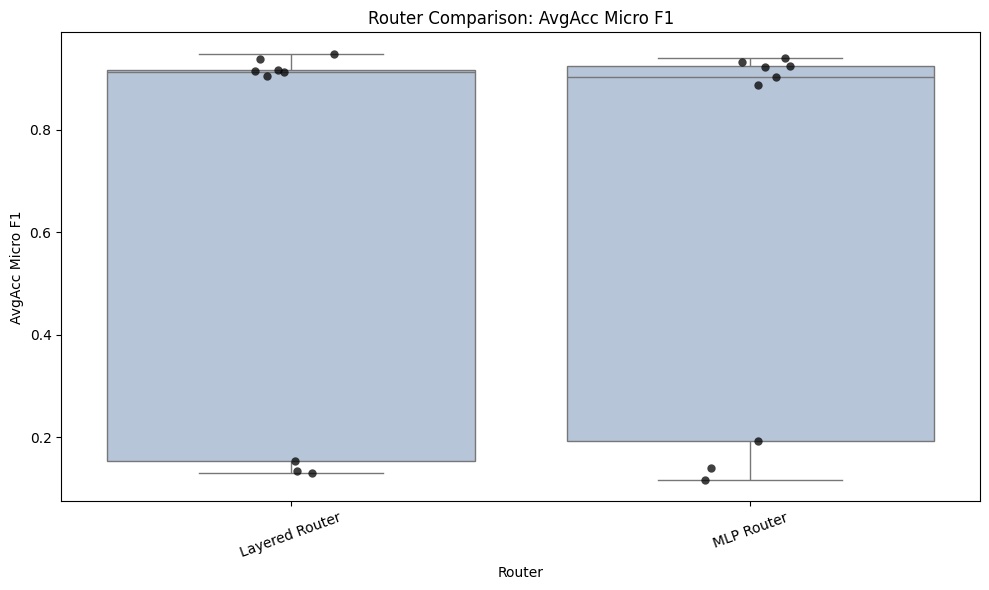

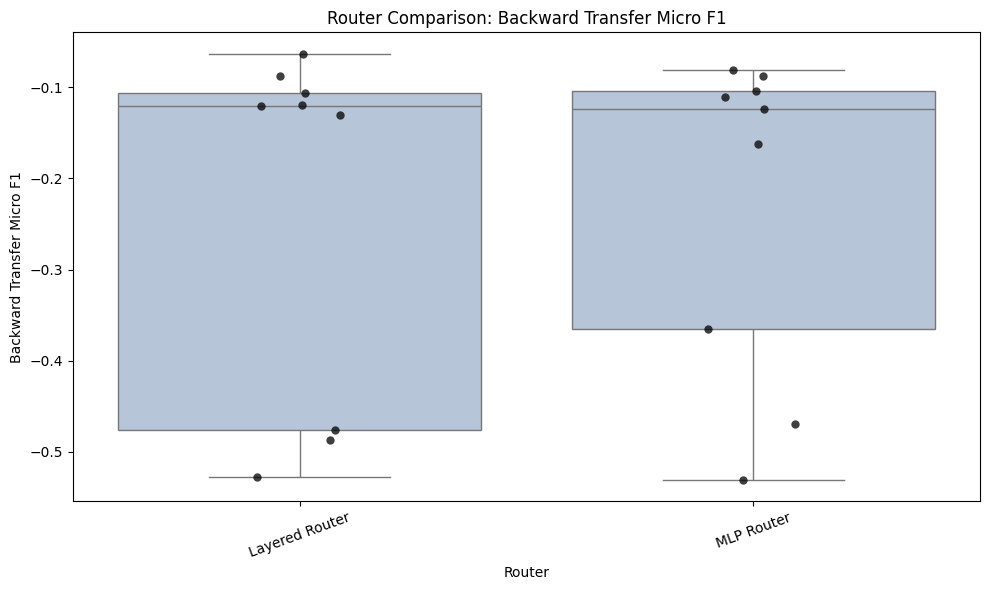

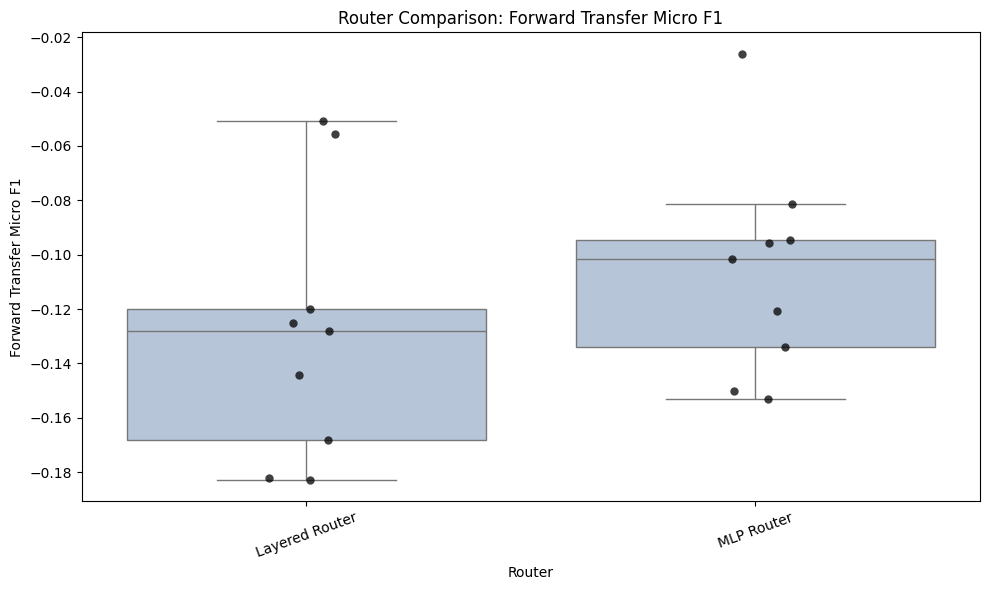

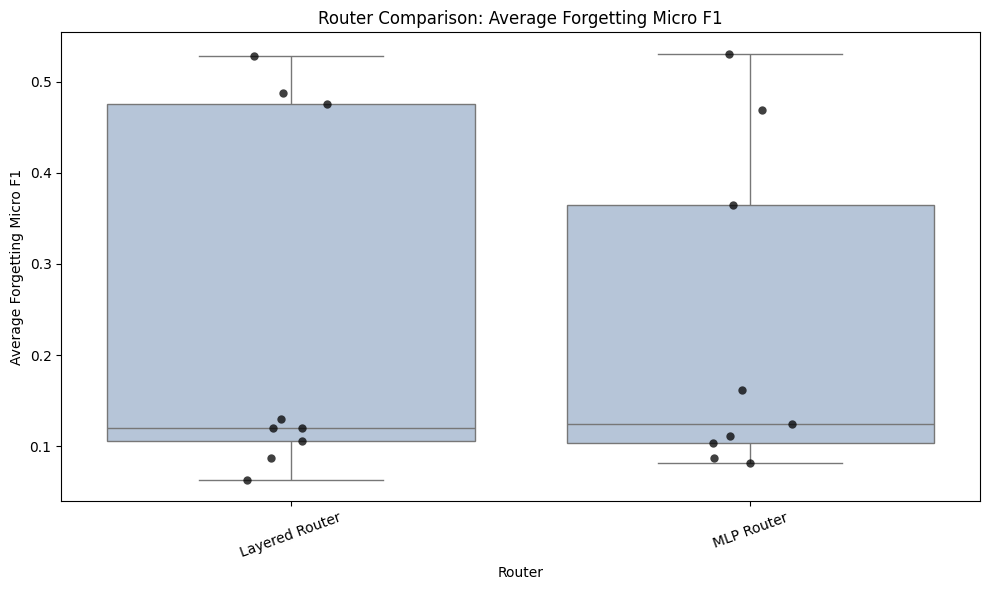

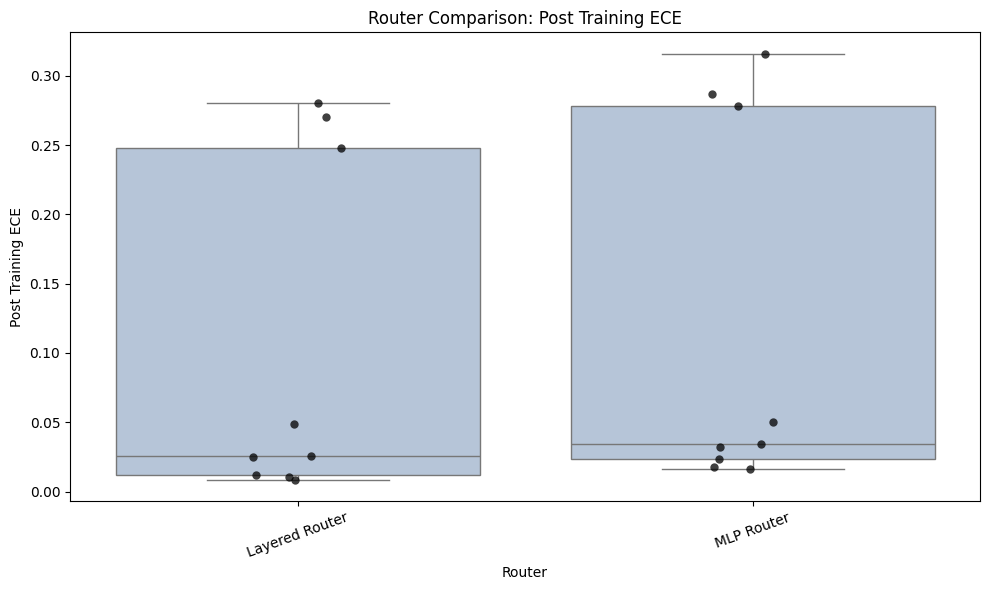

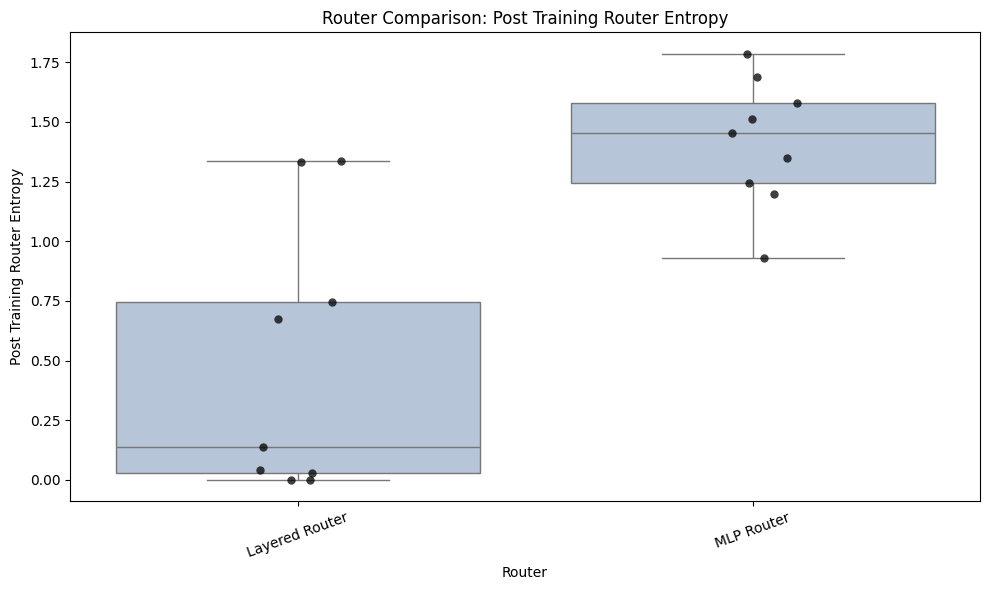

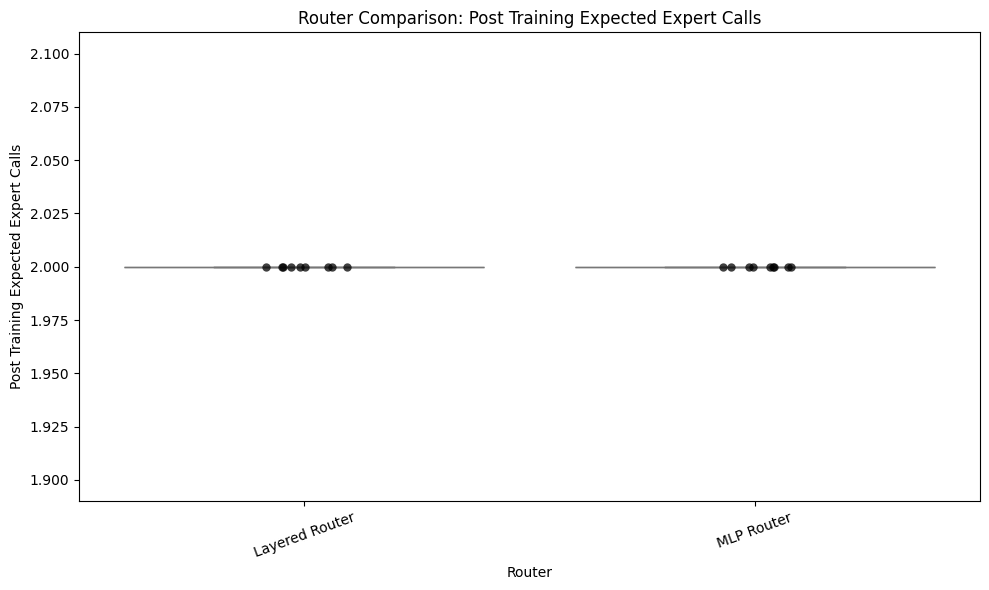

In [28]:
router_plot_metrics = [metric for metric in ['AvgAcc Micro F1', 'Backward Transfer Micro F1', 'Forward Transfer Micro F1', 'Average Forgetting Micro F1', 'Post Training ECE', 'Post Training Router Entropy', 'Post Training Expected Expert Calls'] if metric in submodel_df.columns]
for metric in router_plot_metrics:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=submodel_df, x='Router', y=metric, color='lightsteelblue', fliersize=0)
    sns.stripplot(data=submodel_df, x='Router', y=metric, color='black', alpha=0.75, size=6)
    plt.title(f'Router Comparison: {metric}')
    plt.xlabel('Router')
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

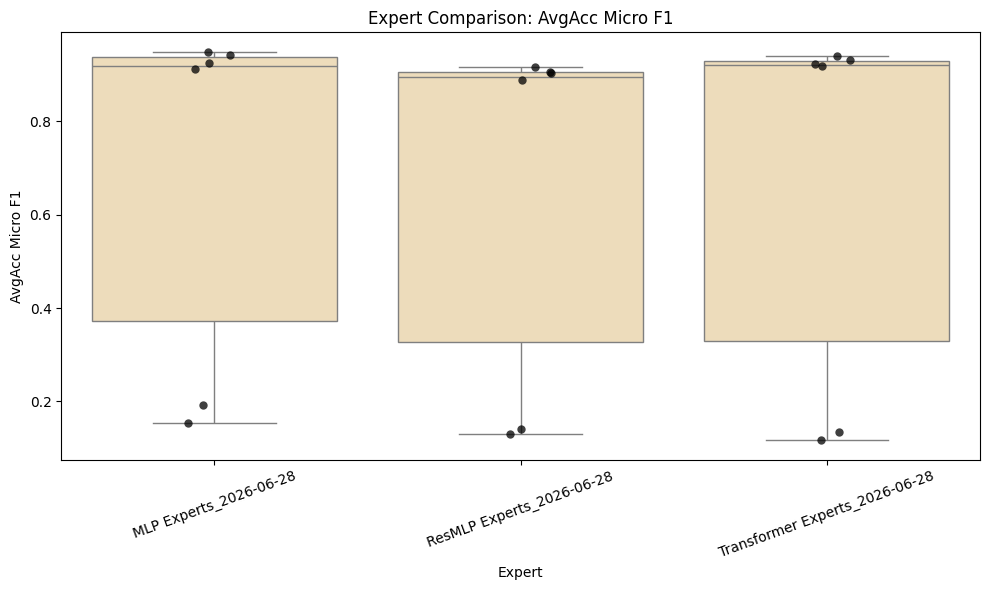

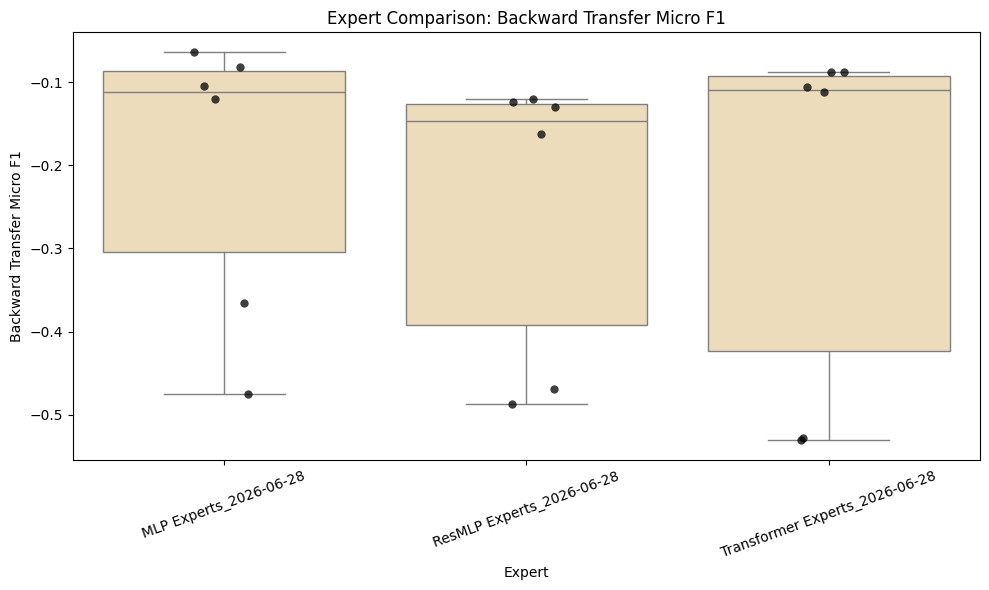

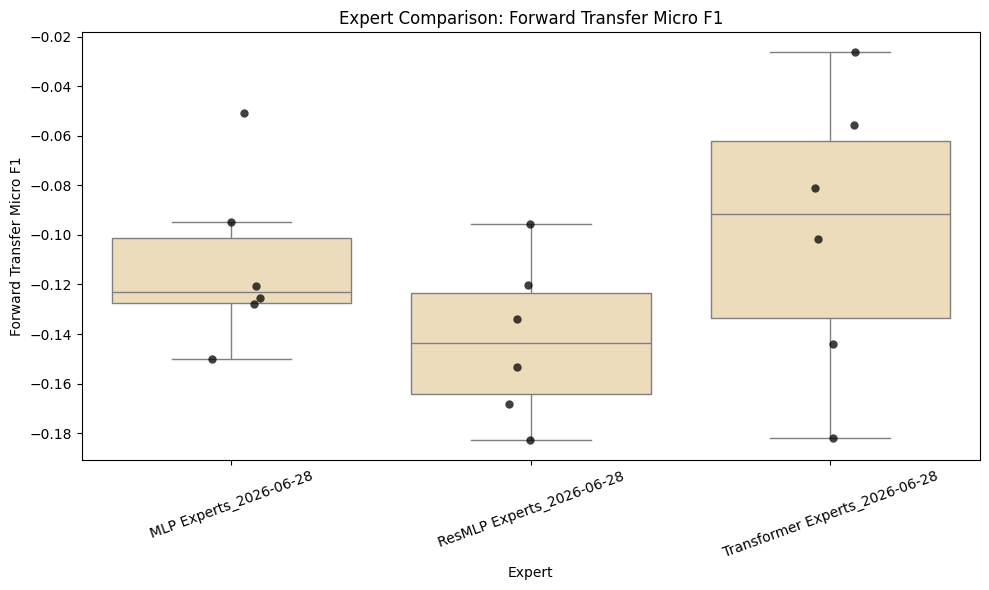

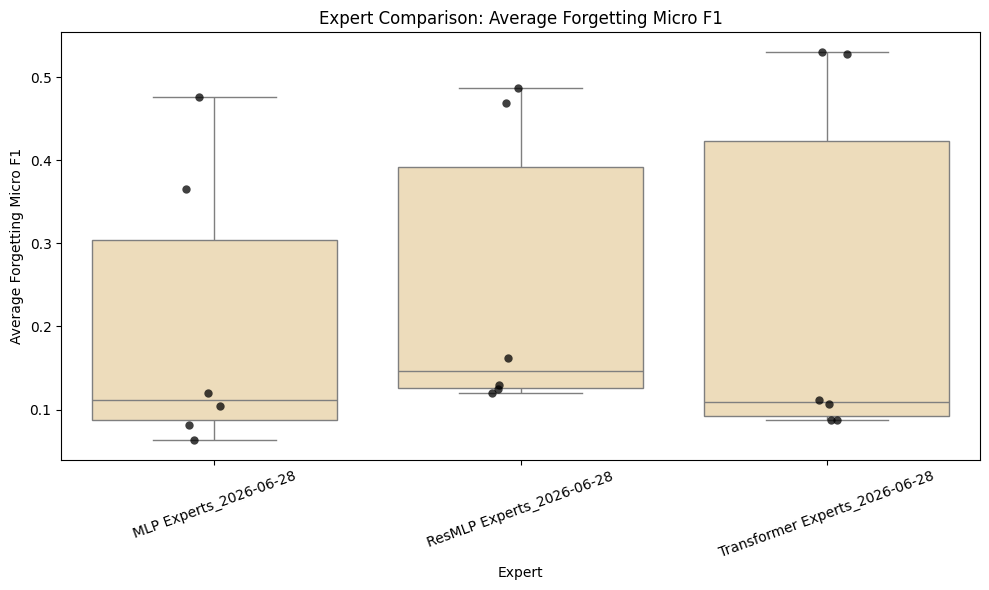

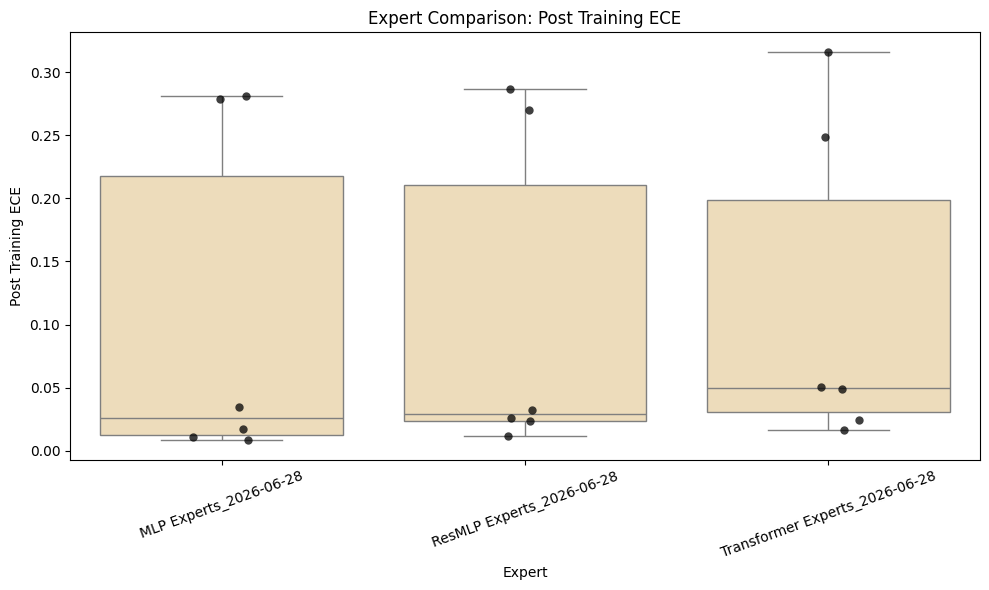

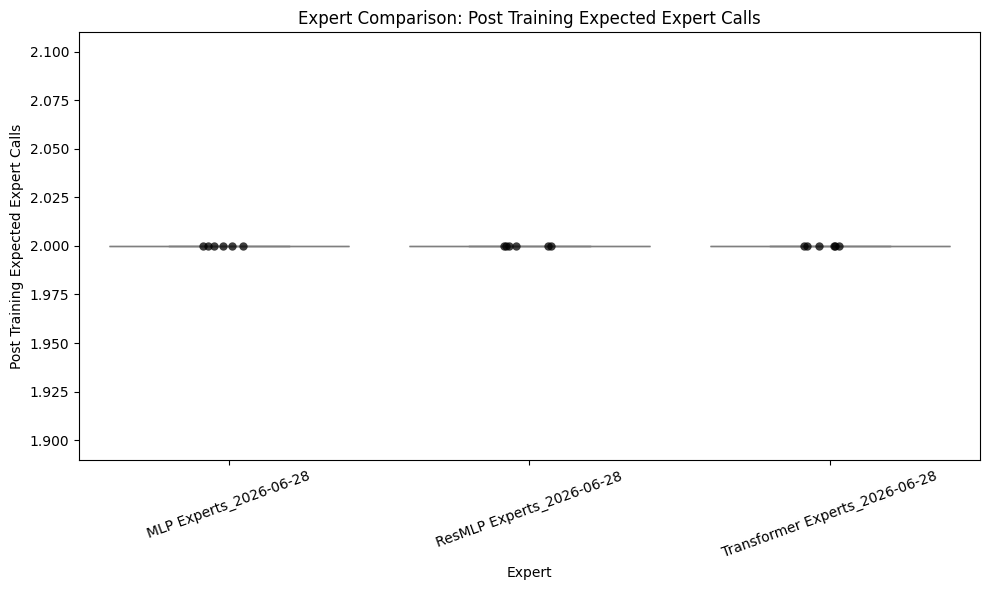

In [29]:
expert_plot_metrics = [metric for metric in ['AvgAcc Micro F1', 'Backward Transfer Micro F1', 'Forward Transfer Micro F1', 'Average Forgetting Micro F1', 'Post Training ECE', 'Post Training Expected Expert Calls'] if metric in submodel_df.columns]
for metric in expert_plot_metrics:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=submodel_df, x='Expert', y=metric, color='wheat', fliersize=0)
    sns.stripplot(data=submodel_df, x='Expert', y=metric, color='black', alpha=0.75, size=6)
    plt.title(f'Expert Comparison: {metric}')
    plt.xlabel('Expert')
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

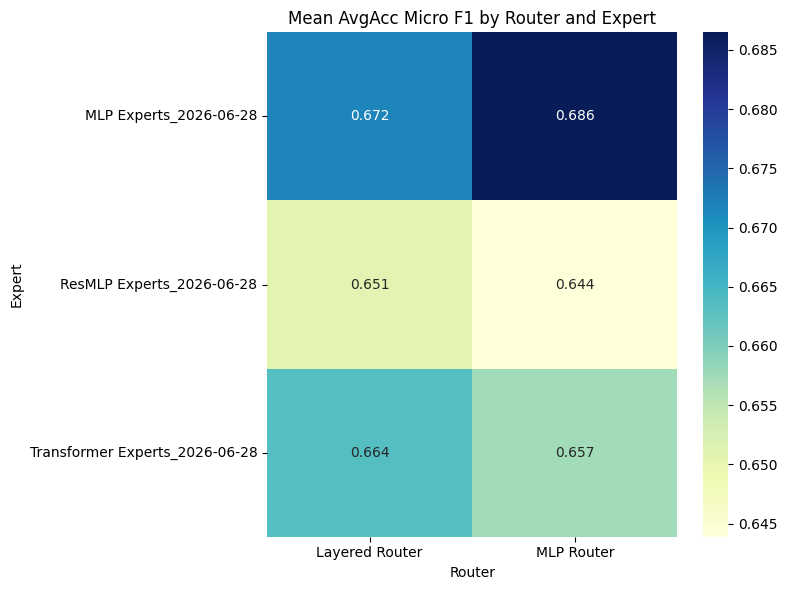

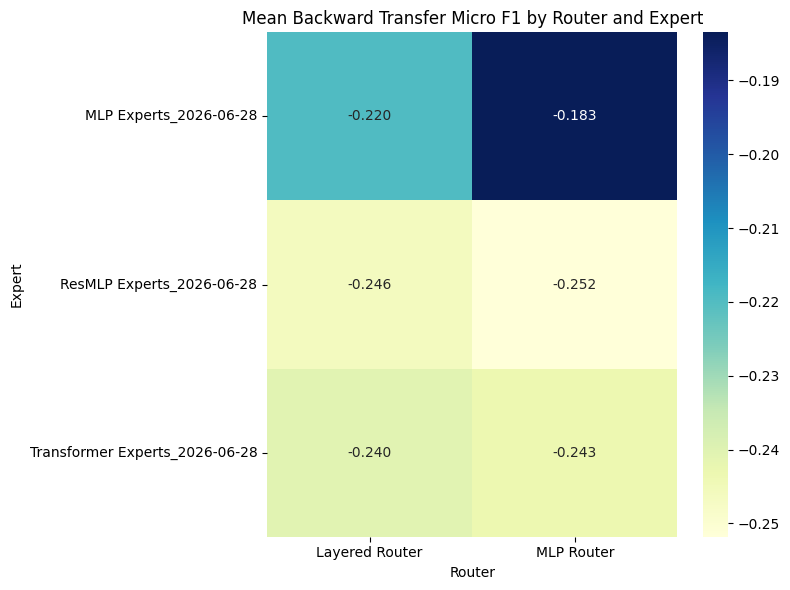

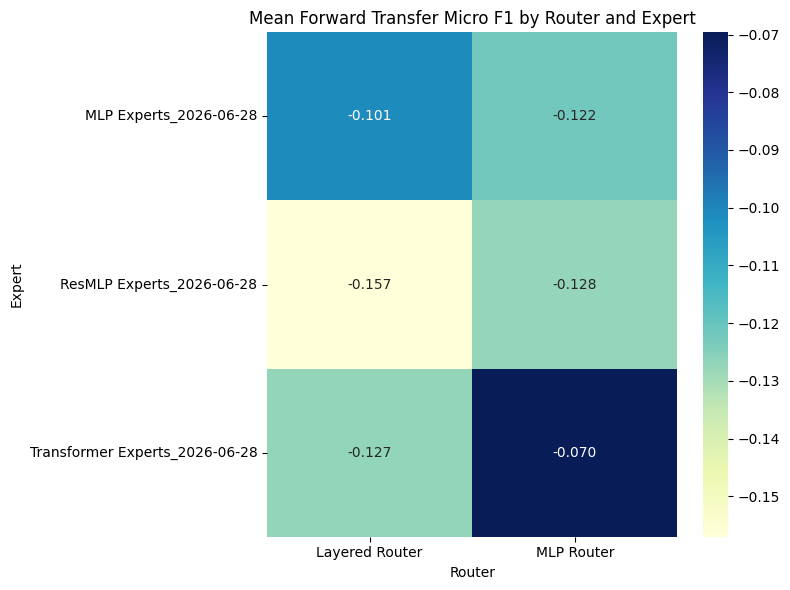

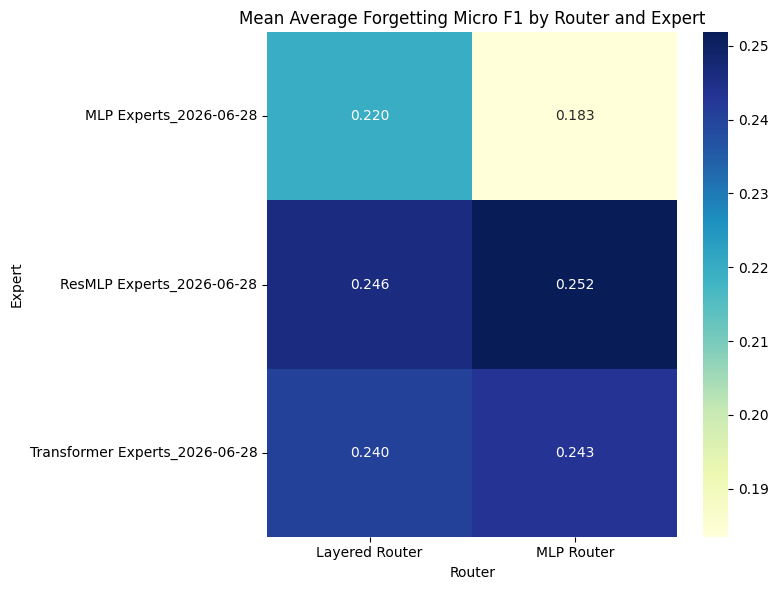

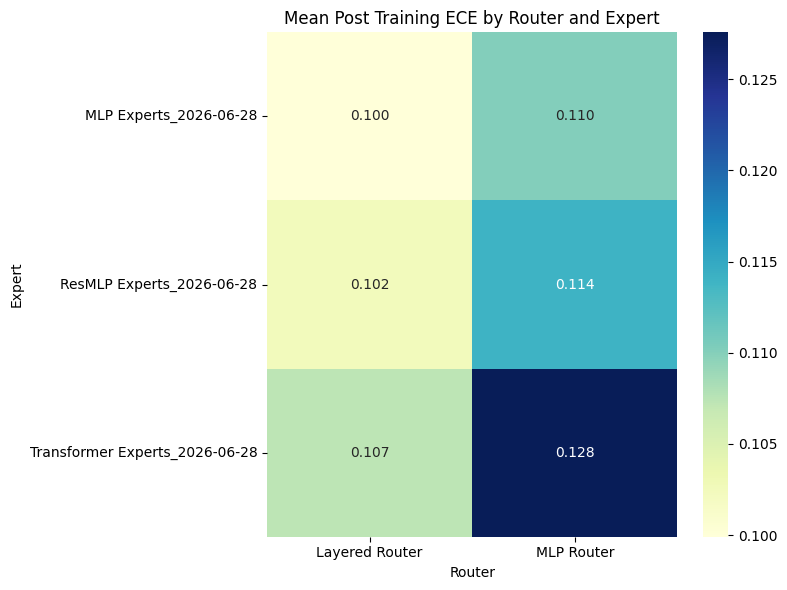

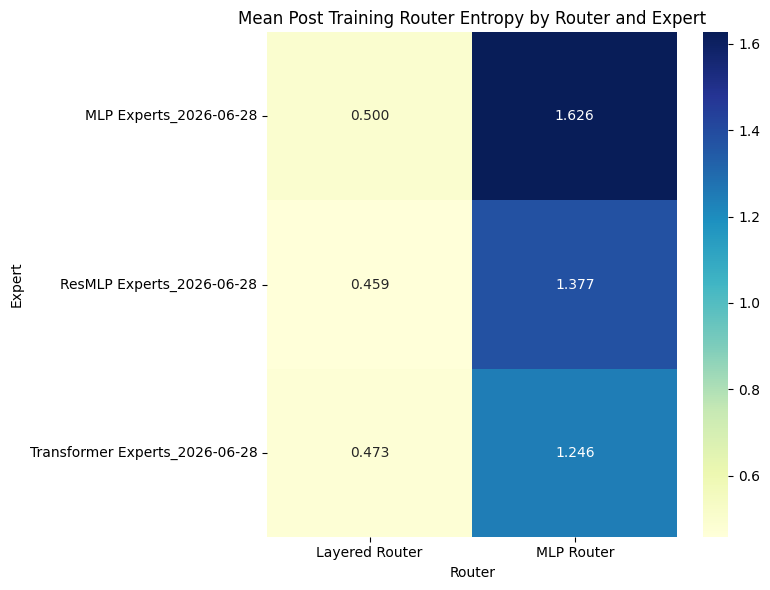

In [30]:
interaction_heatmap_metrics = [metric for metric in ['AvgAcc Micro F1', 'Backward Transfer Micro F1', 'Forward Transfer Micro F1', 'Average Forgetting Micro F1', 'Post Training ECE', 'Post Training Router Entropy'] if metric in submodel_df.columns]
for metric in interaction_heatmap_metrics:
    pivot = submodel_df.pivot_table(index='Expert', columns='Router', values=metric, aggfunc='mean')
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu')
    plt.title(f'Mean {metric} by Router and Expert')
    plt.xlabel('Router')
    plt.ylabel('Expert')
    plt.tight_layout()
    plt.show()